In [ ]:
#CNN
import warnings
warnings.filterwarnings('ignore')

 
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Activation, Dropout, Flatten,BatchNormalization
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Can sıkıcı TF uyarılarını gizler

import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd


Train Sets: (50000, 32, 32, 3) - (50000, 1)
Test Sets: (10000, 32, 32, 3) - (10000, 1)


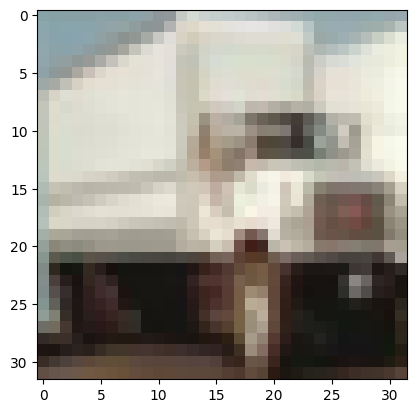

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(
    f'Train Sets: {x_train.shape} - {y_train.shape}\n'
    f'Test Sets: {x_test.shape} - {y_test.shape}'
)

 
x_train[444].shape

 
plt.imshow(x_test[444])

In [ ]:
np.unique(y_train)

mean = np.mean(x_train,axis=(0,1,2),keepdims=True)
std= np.std(x_train,axis=(0,1,2),keepdims=True) + 1e-7
x_train= (x_train - mean) / std
x_test = (x_test - mean ) /std

num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

y_train[444]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=float32)

In [ ]:
model = Sequential(
    [
        Conv2D(32, (3, 3), padding='same', input_shape=x_train.shape[1:]),
        BatchNormalization(), Activation('relu'),
        Conv2D(32, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), padding='same'),
        BatchNormalization(), Activation('relu'),
        Conv2D(64, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Flatten(),
        Dense(512),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.25),
        Dense(10, activation='softmax'),
    ]
)

In [ ]:
opt = keras.optimizers.Adam(
    learning_rate=1e-3
)

model.compile(
    loss='categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

batch_size = 64
epochs = 50

history = model.fit(
    datagen.flow(
        x_train,
        y_train,
        batch_size=batch_size
    ),
    epochs = epochs,
    validation_data=(x_test, y_test),
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(
            factor=0.5,
            patience=5,
            min_lr=1e-5,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            patience=10,
            restore_best_weights=True
        )
    ]
) 

Epoch 1/50
782/782 [==============================] - 107s 134ms/step - loss: 1.4258 - accuracy: 0.4954 - val_loss: 1.2503 - val_accuracy: 0.5628 - lr: 0.0010
Epoch 2/50
340/782 [============>.................] - ETA: 56s - loss: 1.0837 - accuracy: 0.6131

In [ ]:
model_1 = Sequential()

model_1.add(Conv2D(32,(5,5),strides=(2,2),padding='same',input_shape=x_train.shape[1:]))
model_1.add(Activation('relu'))

model_1.add(Conv2D(32,(5,5),strides=(2,2)))
model_1.add(Activation('relu'))

model_1.add(MaxPooling2D(pool_size=(2,2)))
model_1.add(Dropout(0.25))

model_1.add(Flatten())
model_1.add(Dense(512))
model_1.add(Activation('relu'))
model_1.add(Dropout(0.5))
model_1.add(Dense(num_classes))

model_1.add(Activation('softmax'))

model_1.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 16, 16, 32)        2432      
                                                                 
 activation_5 (Activation)   (None, 16, 16, 32)        0         
                                                                 
 conv2d_5 (Conv2D)           (None, 6, 6, 32)          25632     
                                                                 
 activation_6 (Activation)   (None, 6, 6, 32)          0         
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 3, 3, 32)          0         
 g2D)                                                            
                                                                 
 dropout_3 (Dropout)         (None, 3, 3, 32)          0         
                                                      

In [ ]:
batch_size = 32

opt = keras.optimizers.legacy.RMSprop(
    learning_rate=0.005,
    decay=1e-6
)

model_1.compile(
    loss='categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

history = model_1.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=15,
    validation_data=(x_test, y_test),
    shuffle=True
)

Epoch 1/15


1563/1563 [==============================] - 15s 9ms/step - loss: 2.1260 - accuracy: 0.2221 - val_loss: 1.9410 - val_accuracy: 0.2639
Epoch 2/15
1563/1563 [==============================] - 12s 8ms/step - loss: 2.1823 - accuracy: 0.2145 - val_loss: 2.0756 - val_accuracy: 0.2208
Epoch 3/15
1563/1563 [==============================] - 13s 8ms/step - loss: 2.1525 - accuracy: 0.2168 - val_loss: 2.1380 - val_accuracy: 0.1921
Epoch 4/15
1563/1563 [==============================] - 13s 8ms/step - loss: 2.1183 - accuracy: 0.2107 - val_loss: 2.1514 - val_accuracy: 0.1786
Epoch 5/15
1563/1563 [==============================] - 14s 9ms/step - loss: 2.1001 - accuracy: 0.2021 - val_loss: 1.9950 - val_accuracy: 0.2095
Epoch 6/15
1563/1563 [==============================] - 12s 8ms/step - loss: 2.1406 - accuracy: 0.1855 - val_loss: 2.0564 - val_accuracy: 0.2094
Epoch 7/15
1563/1563 [==============================] - 12s 7ms/step - loss: 2.1587 - accuracy: 0.1815 - val_loss: 2.0913 - val_

In [ ]:
model_2 = Sequential()

model_2.add(Conv2D(32, (3, 3), padding='same', input_shape=x_train.shape[1:]))
model_2.add(Activation('relu'))
model_2.add(Conv2D(32, (3, 3)))
model_2.add(Activation('relu'))
model_2.add(MaxPooling2D(pool_size=(2, 2)))
model_2.add(Dropout(0.25))

model_2.add(Conv2D(64, (3, 3), padding='same'))
model_2.add(Activation('relu'))
model_2.add(Conv2D(64, (3, 3)))
model_2.add(Activation('relu'))
model_2.add(MaxPooling2D(pool_size=(2, 2)))
model_2.add(Dropout(0.25))

model_2.add(Flatten())
model_2.add(Dense(512))
model_2.add(Activation('relu'))
model_2.add(Dropout(0.5))
model_2.add(Dense(num_classes))
model_2.add(Activation('softmax'))

model_2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 activation_4 (Activation)   (None, 32, 32, 32)        0         
                                                                 
 conv2d_3 (Conv2D)           (None, 30, 30, 32)        9248      
                                                                 
 activation_5 (Activation)   (None, 30, 30, 32)        0         
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 15, 15, 32)        0         
                                                      

In [ ]:

opt_2 = keras.optimizers.legacy.RMSprop(
    learning_rate=0.005,
    decay=1e-6
)

model_2.compile(
    loss='categorical_crossentropy',
    optimizer=opt_2,
    metrics=['accuracy']
)


history_2 = model_2.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=10,
    validation_data=(x_test, y_test),
    shuffle=True
)

Epoch 1/10
1563/1563 [==============================] - 75s 47ms/step - loss: 1.9673 - accuracy: 0.3053 - val_loss: 1.6311 - val_accuracy: 0.3916
Epoch 2/10
1563/1563 [==============================] - 87s 55ms/step - loss: 1.8420 - accuracy: 0.3323 - val_loss: 1.9780 - val_accuracy: 0.2502
Epoch 3/10
1563/1563 [==============================] - 70s 45ms/step - loss: 1.8743 - accuracy: 0.3111 - val_loss: 1.7651 - val_accuracy: 0.3418
Epoch 4/10
1563/1563 [==============================] - 78s 50ms/step - loss: 1.9163 - accuracy: 0.2937 - val_loss: 1.8486 - val_accuracy: 0.3256
Epoch 5/10
1563/1563 [==============================] - 79s 50ms/step - loss: 1.9064 - accuracy: 0.2979 - val_loss: 1.8587 - val_accuracy: 0.3133
Epoch 6/10
1563/1563 [==============================] - 78s 50ms/step - loss: 1.9280 - accuracy: 0.2868 - val_loss: 1.8639 - val_accuracy: 0.3124
Epoch 7/10
1563/1563 [==============================] - 85s 55ms/step - loss: 1.9516 - accuracy: 0.2741 - val_loss: 2.1350 -

In [ ]:
y_test_trans = np.argmax(y_test, axis=1)

y_pred = np.argmax(model_2.predict(x_test), axis=1)

In [ ]:


def print_accuracy_result(y_test, y_pred):
    clsf_report = pd.DataFrame(
        classification_report(y_test, y_pred, output_dict=True)
    )
    print(
        f'Accuracy Score: {accuracy_score(y_test, y_pred)}\n'   
        f'======================================================\n'
        f'Classification Report:\n{clsf_report}\n'
        f'======================================================\n'
        f'Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}'
    )

In [ ]:
print_accuracy_result(
    y_test=y_test_trans,
    y_pred=y_pred
)

In [ ]:
plt.imshow(x_test[444])

NameError: name 'x_test' is not defined

In [ ]:
def predict_with_probs(idx):
    img = x_test[idx]
    true_class = y_test_trans[idx]

    probs = model_2.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_class = np.argmax(probs)

    restored_img = (img * std + mean).astype(np.uint8)

    if restored_img.ndim == 4:
        restored_img = restored_img[0]

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].imshow(restored_img)
    axs[0].axis('off')
    axs[0].set_title(f'Gerçek: {cifar10_labels[true_class]}\nTahmin : {cifar10_labels[pred_class]}')

    axs[1].barh(cifar10_labels, probs, color='skyblue')
    axs[1].set_xlim(0, 1)
    axs[1].set_title('Class Probality')
    axs[1].invert_yaxis()
    for i, v in enumerate(probs):
        axs[1].text(v + 0.01, i, f'{v:.2f}', va='center')

    plt.tight_layout()
    plt.show()

predict_with_probs(444)

NameError: name 'x_test' is not defined